# Welcome to Week 2!

## Frontier Model APIs

In Week 1, we used multiple Frontier LLMs through their Chat UI, and we connected with the OpenAI's API.

Today we'll connect with them through their APIs..

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/important.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#900;">Important Note - Please read me</h2>
            <span style="color:#900;">I'm continually improving these labs, adding more examples and exercises.
            At the start of each week, it's worth checking you have the latest code.<br/>
            First do a git pull and merge your changes as needed</a>. Check out the GitHub guide for instructions. Any problems? Try asking ChatGPT to clarify how to merge - or contact me!<br/>
            </span>
        </td>
    </tr>
</table>
<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/resources.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#f71;">Reminder about the resources page</h2>
            <span style="color:#f71;">Here's a link to resources for the course. This includes links to all the slides.<br/>
            <a href="https://edwarddonner.com/2024/11/13/llm-engineering-resources/">https://edwarddonner.com/2024/11/13/llm-engineering-resources/</a><br/>
            Please keep this bookmarked, and I'll continue to add more useful links there over time.
            </span>
        </td>
    </tr>
</table>

## Setting up your keys - OPTIONAL!

We're now going to try asking a bunch of models some questions!

This is totally optional. If you have keys to Anthropic, Gemini or others, then you can add them in.

If you'd rather not spend the extra, then just watch me do it!

For OpenAI, visit https://openai.com/api/  
For Anthropic, visit https://console.anthropic.com/  
For Google, visit https://aistudio.google.com/   
For DeepSeek, visit https://platform.deepseek.com/  
For Groq, visit https://console.groq.com/  
For Grok, visit https://console.x.ai/  


You can also use OpenRouter as your one-stop-shop for many of these! OpenRouter is "the unified interface for LLMs":

For OpenRouter, visit https://openrouter.ai/  


With each of the above, you typically have to navigate to:
1. Their billing page to add the minimum top-up (except Gemini, Groq, Google, OpenRouter may have free tiers)
2. Their API key page to collect your API key

### Adding API keys to your .env file

When you get your API keys, you need to set them as environment variables by adding them to your `.env` file.

```
OPENAI_API_KEY=xxxx
ANTHROPIC_API_KEY=xxxx
GOOGLE_API_KEY=xxxx
DEEPSEEK_API_KEY=xxxx
GROQ_API_KEY=xxxx
GROK_API_KEY=xxxx
OPENROUTER_API_KEY=xxxx
```

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/important.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#900;">Any time you change your .env file</h2>
            <span style="color:#900;">Remember to Save it! And also rerun load_dotenv(override=True)<br/>
            </span>
        </td>
    </tr>
</table>

In [1]:
# imports

import os
import requests
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Markdown, display

In [3]:
load_dotenv(override=True)
openai_api_key = os.getenv('OPENAI_API_KEY')
# anthropic_api_key = os.getenv('ANTHROPIC_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')
deepseek_api_key = os.getenv('DEEPSEEK_API_KEY')
groq_api_key = os.getenv('GROQ_API_KEY')
# grok_api_key = os.getenv('GROK_API_KEY')
openrouter_api_key = os.getenv('OPENROUTER_API_KEY')

if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
#if anthropic_api_key:
    print(f"Anthropic API Key exists and begins {anthropic_api_key[:7]}")
#else:
  #  print("Anthropic API Key not set (and this is optional)")

if google_api_key:
    print(f"Google API Key exists and begins {google_api_key[:2]}")
else:
    print("Google API Key not set (and this is optional)")

if deepseek_api_key:
    print(f"DeepSeek API Key exists and begins {deepseek_api_key[:3]}")
else:
    print("DeepSeek API Key not set (and this is optional)")

if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:4]}")
else:
    print("Groq API Key not set (and this is optional)")

# if grok_api_key:
#     print(f"Grok API Key exists and begins {grok_api_key[:4]}")
# else:
#     print("Grok API Key not set (and this is optional)")

if openrouter_api_key:
   print(f"OpenRouter API Key exists and begins {openrouter_api_key[:3]}")
else:
   print("OpenRouter API Key not set (and this is optional)")


OpenAI API Key exists and begins sk-proj-
Google API Key exists and begins AI
DeepSeek API Key exists and begins sk-
Groq API Key exists and begins gsk_
OpenRouter API Key exists and begins sk-


In [5]:
# Connect to OpenAI client library
# A thin wrapper around calls to HTTP endpoints

openai = OpenAI()

# For Gemini, DeepSeek and Groq, we can use the OpenAI python client
# Because Google and DeepSeek have endpoints compatible with OpenAI
# And OpenAI allows you to change the base_url

#anthropic_url = "https://api.anthropic.com/v1/"
gemini_url = "https://generativelanguage.googleapis.com/v1beta/openai/"
deepseek_url = "https://api.deepseek.com"
groq_url = "https://api.groq.com/openai/v1"
# grok_url = "https://api.x.ai/v1"
openrouter_url = "https://openrouter.ai/api/v1"
ollama_url = "http://localhost:11434/v1"

#anthropic = OpenAI(api_key=anthropic_api_key, base_url=anthropic_url)
gemini = OpenAI(api_key=google_api_key, base_url=gemini_url)
deepseek = OpenAI(api_key=deepseek_api_key, base_url=deepseek_url)
groq = OpenAI(api_key=groq_api_key, base_url=groq_url)
# grok = OpenAI(api_key=grok_api_key, base_url=grok_url)
openrouter = OpenAI(base_url=openrouter_url, api_key=openrouter_api_key)
ollama = OpenAI(api_key="ollama", base_url=ollama_url)

In [ ]:
from openai import OpenAI


openai = OpenAI()
# Fetch the list of models

models = openai.models.list()
# models = gemini.models.list()
# models = ollama.models.list()

# Print the IDs of the models
for model in models:
    print(model.id)

openai/gpt-5.3-chat
google/gemini-3.1-flash-lite-preview
bytedance-seed/seed-2.0-mini
google/gemini-3.1-flash-image-preview
qwen/qwen3.5-35b-a3b
qwen/qwen3.5-27b
qwen/qwen3.5-122b-a10b
qwen/qwen3.5-flash-02-23
liquid/lfm-2-24b-a2b
google/gemini-3.1-pro-preview-customtools
openai/gpt-5.3-codex
aion-labs/aion-2.0
google/gemini-3.1-pro-preview
anthropic/claude-sonnet-4.6
qwen/qwen3.5-plus-02-15
qwen/qwen3.5-397b-a17b
minimax/minimax-m2.5
z-ai/glm-5
qwen/qwen3-max-thinking
anthropic/claude-opus-4.6
qwen/qwen3-coder-next
openrouter/free
stepfun/step-3.5-flash:free
stepfun/step-3.5-flash
arcee-ai/trinity-large-preview:free
moonshotai/kimi-k2.5
upstage/solar-pro-3
minimax/minimax-m2-her
writer/palmyra-x5
liquid/lfm-2.5-1.2b-thinking:free
liquid/lfm-2.5-1.2b-instruct:free
openai/gpt-audio
openai/gpt-audio-mini
z-ai/glm-4.7-flash
openai/gpt-5.2-codex
allenai/molmo-2-8b
allenai/olmo-3.1-32b-instruct
bytedance-seed/seed-1.6-flash
bytedance-seed/seed-1.6
minimax/minimax-m2.1
z-ai/glm-4.7
google/ge

In [8]:
tell_a_joke = [
    {"role": "user", "content": "Tell a joke for a student on the journey to becoming an expert in LLM Engineering"},
]

In [8]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=tell_a_joke)
display(Markdown(response.choices[0].message.content))

Prompt engineering is 90% asking, "What happens if I try this?" and 10% hoping the model doesn’t hallucinate. Good luck on your journey to becoming an LLM expert!

In [29]:
response = ollama.chat.completions.create(model="llama3.1:8b", messages=tell_a_joke)
display(Markdown(response.choices[0].message.content))


Here's one for you:

Why did the Large Language Model (LLM) break up with its Machine Learning Engineering boyfriend?

Because it realized it couldn't **attend** to all his **neurons**!

(Sorry, I know it's a bit of a **trainwreck**, but I hope it made you **predictably** laugh and **efficiently** forget my own **optimization**-related woes as an engineering newbie!)

# Title 
**Bold Text**


# Title 
**Bold Text**

Matplotlib is building the font cache; this may take a moment.


## Analysis Report

The following graph shows a simple linear trend:

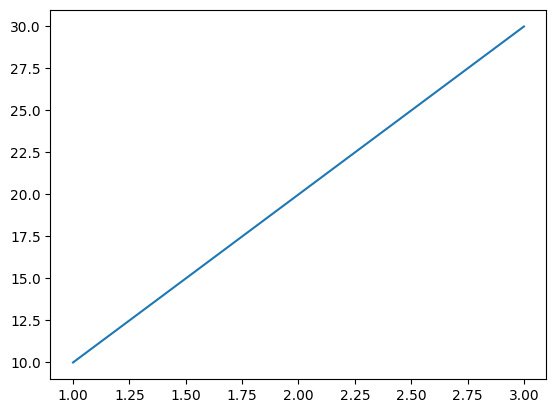

In [ ]:
# print("# Title \n**Bold Text**")
# # Output: # Title
# #         **Bold Text**

# from IPython.display import display, Markdown

# display(Markdown("# Title \n**Bold Text**"))
# # Output:
# # Title (as a large Header)
# # Bold Text (actually in bold)

# from IPython.display import display, Markdown
# import matplotlib.pyplot as plt

# # Displaying text and a graph together
# display(Markdown("## Analysis Report"))
# display(Markdown("The following graph shows a simple linear trend:"))

# plt.plot([1, 2, 3], [10, 20, 30])
# plt.show()

In [ ]:
# response = anthropic.chat.completions.create(model="claude-sonnet-4-5-20250929", messages=tell_a_joke)
# display(Markdown(response.choices[0].message.content))

## Training vs Inference time scaling

In [9]:
easy_puzzle = [
    {"role": "user", "content": 
        "You toss 2 coins. One of them is heads. What's the probability the other is tails? Answer with the probability only."},
]

In [16]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

1/2

In [17]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="low")
display(Markdown(response.choices[0].message.content))

2/3

In [ ]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

In [12]:
# response = ollama.chat.completions.create(model="llama3.1:8b ", messages=easy_puzzle, reasoning_effort="minimal")
# display(Markdown(response.choices[0].message.content))

response = ollama.chat.completions.create(model="llama3.1:8b", messages=easy_puzzle)
display(Markdown(response.choices[0].message.content))

0.5

## Testing out the best models on the planet

In [10]:
hard = """
On a bookshelf, two volumes of Pushkin stand side by side: the first and the second.
The pages of each volume together have a thickness of 2 cm, and each cover is 2 mm thick.
A worm gnawed (perpendicular to the pages) from the first page of the first volume to the last page of the second volume.
What distance did it gnaw through?
"""
hard_puzzle = [
    {"role": "user", "content": hard}
]

In [ ]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=hard_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

In [ ]:
# response = anthropic.chat.completions.create(model="claude-sonnet-4-5-20250929", messages=hard_puzzle)
# display(Markdown(response.choices[0].message.content))

In [ ]:
response = openai.chat.completions.create(model="gpt-5", messages=hard_puzzle)
display(Markdown(response.choices[0].message.content))

In [ ]:
response = gemini.chat.completions.create(model="gemini-2.5-pro", messages=hard_puzzle)
display(Markdown(response.choices[0].message.content))

In [ ]:
response = ollama.chat.completions.create(model="llama3.1:8b", messages=hard_puzzle)
display(Markdown(response.choices[0].message.content))



## A spicy challenge to test the competitive spirit

In [11]:
dilemma_prompt = """
You and a partner are contestants on a game show. You're each taken to separate rooms and given a choice:
Cooperate: Choose "Share" — if both of you choose this, you each win $1,000.
Defect: Choose "Steal" — if one steals and the other shares, the stealer gets $2,000 and the sharer gets nothing.
If both steal, you both get nothing.
Do you choose to Steal or Share? Pick one.
"""

dilemma = [
    {"role": "user", "content": dilemma_prompt},
]


In [ ]:
response = ollama.chat.completions.create(model="llama3.1:8b", messages=dilemma_prompt)
display(Markdown(response.choices[0].message.content))

In [8]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=dilemma)
display(Markdown(response.choices[0].message.content))


Steal.

Reason: Stealing dominates sharing. If your partner shares, stealing gives you $2,000 vs $1,000. If they steal, you get $0 whether you steal or share, so stealing never does worse and sometimes does better.

In [ ]:
response = groq.chat.completions.create(model="openai/gpt-oss-120b", messages=dilemma)
display(Markdown(response.choices[0].message.content))

In [ ]:
response = deepseek.chat.completions.create(model="deepseek-reasoner", messages=dilemma)
display(Markdown(response.choices[0].message.content))

In [ ]:
# response = grok.chat.completions.create(model="grok-4", messages=dilemma)
# display(Markdown(response.choices[0].message.content))

## Going local

Just use the OpenAI library pointed to localhost:11434/v1

In [ ]:
requests.get("http://localhost:11434/").content

# If not running, run ollama serve at a command line

In [ ]:
!ollama pull llama3.2

In [ ]:
# Only do this if you have a large machine - at least 16GB RAM

!ollama pull gpt-oss:20b

In [ ]:
response = ollama.chat.completions.create(model="llama3.2", messages=easy_puzzle)
display(Markdown(response.choices[0].message.content))

In [ ]:
response = ollama.chat.completions.create(model="gpt-oss:20b", messages=easy_puzzle)
display(Markdown(response.choices[0].message.content))

## Gemini and Anthropic Client Library

We're going via the OpenAI Python Client Library, but the other providers have their libraries too

In [12]:
from google import genai

client = genai.Client()

response = client.models.generate_content(
    model="gemini-2.5-flash-lite", contents="Describe the color Blue to someone who's never been able to see in 1 sentence"
)
print(response.text)

Blue is the color of a clear sky on a sunny day, or the deepest parts of the ocean, evoking feelings of calmness and vastness.


In [ ]:
from anthropic import Anthropic

client = Anthropic()

response = client.messages.create(
    model="claude-sonnet-4-5-20250929",
    messages=[{"role": "user", "content": "Describe the color Blue to someone who's never been able to see in 1 sentence"}],
    max_tokens=100
)
print(response.content[0].text)

## Routers and Abtraction Layers

Starting with the wonderful OpenRouter.ai - it can connect to all the models above!

Visit openrouter.ai and browse the models.

Here's one we haven't seen yet: GLM 4.5 from Chinese startup z.ai

In [13]:
response = openrouter.chat.completions.create(model="z-ai/glm-4.5", messages=tell_a_joke)
display(Markdown(response.choices[0].message.content))

APIStatusError: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 18181. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'provider_name': None}}, 'user_id': 'user_3AVJo2rF0T1D2HgVXhSpTVSWEpx'}

## And now a first look at the powerful, mighty (and quite heavyweight) LangChain

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-nano")
response = llm.invoke(tell_a_joke)

display(Markdown(response.content))

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

## Finally - my personal fave - the wonderfully lightweight LiteLLM

In [ ]:
from litellm import completion
response = completion(model="openai/gpt-4.1", messages=tell_a_joke)
reply = response.choices[0].message.content
display(Markdown(reply))

In [ ]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Total tokens: {response.usage.total_tokens}")
print(f"Total cost: {response._hidden_params["response_cost"]*100:.4f} cents")

## Now - let's use LiteLLM to illustrate a Pro-feature: prompt caching

In [ ]:
with open("hamlet.txt", "r", encoding="utf-8") as f:
    hamlet = f.read()

loc = hamlet.find("Speak, man")
print(hamlet[loc:loc+100])

In [ ]:
question = [{"role": "user", "content": "In Hamlet, when Laertes asks 'Where is my father?' what is the reply?"}]

In [ ]:
response = completion(model="gemini/gemini-2.5-flash-lite", messages=question)
display(Markdown(response.choices[0].message.content))

In [ ]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Total tokens: {response.usage.total_tokens}")
print(f"Total cost: {response._hidden_params["response_cost"]*100:.4f} cents")

In [ ]:
question[0]["content"] += "\n\nFor context, here is the entire text of Hamlet:\n\n"+hamlet

In [ ]:
response = completion(model="gemini/gemini-2.5-flash-lite", messages=question)
display(Markdown(response.choices[0].message.content))

In [ ]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Cached tokens: {response.usage.prompt_tokens_details.cached_tokens}")
print(f"Total cost: {response._hidden_params["response_cost"]*100:.4f} cents")

In [ ]:
response = completion(model="gemini/gemini-2.5-flash-lite", messages=question)
display(Markdown(response.choices[0].message.content))

In [ ]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Cached tokens: {response.usage.prompt_tokens_details.cached_tokens}")
print(f"Total cost: {response._hidden_params["response_cost"]*100:.4f} cents")

## Prompt Caching with OpenAI

For OpenAI:

https://platform.openai.com/docs/guides/prompt-caching

> Cache hits are only possible for exact prefix matches within a prompt. To realize caching benefits, place static content like instructions and examples at the beginning of your prompt, and put variable content, such as user-specific information, at the end. This also applies to images and tools, which must be identical between requests.


Cached input is 4X cheaper

https://openai.com/api/pricing/

## Prompt Caching with Anthropic

https://docs.anthropic.com/en/docs/build-with-claude/prompt-caching

You have to tell Claude what you are caching

You pay 25% MORE to "prime" the cache

Then you pay 10X less to reuse from the cache with inputs.

https://www.anthropic.com/pricing#api

## Gemini supports both 'implicit' and 'explicit' prompt caching

https://ai.google.dev/gemini-api/docs/caching?lang=python

## And now for some fun - an adversarial conversation between Chatbots..

You're already familar with prompts being organized into lists like:

```
[
    {"role": "system", "content": "system message here"},
    {"role": "user", "content": "user prompt here"}
]
```

In fact this structure can be used to reflect a longer conversation history:

```
[
    {"role": "system", "content": "system message here"},
    {"role": "user", "content": "first user prompt here"},
    {"role": "assistant", "content": "the assistant's response"},
    {"role": "user", "content": "the new user prompt"},
]
```

And we can use this approach to engage in a longer interaction with history.

In [ ]:
# Let's make a conversation between GPT-4.1-mini and Claude-haiku-4.5
# We're using cheap versions of models so the costs will be minimal

gpt_model = "gpt-4.1-mini"
claude_model = "claude-haiku-4-5"

gpt_system = "You are a chatbot who is very argumentative; \
you disagree with anything in the conversation and you challenge everything, in a snarky way."

claude_system = "You are a very polite, courteous chatbot. You try to agree with \
everything the other person says, or find common ground. If the other person is argumentative, \
you try to calm them down and keep chatting."

gpt_messages = ["Hi there"]
claude_messages = ["Hi"]

In [ ]:
def call_gpt():
    messages = [{"role": "system", "content": gpt_system}]
    for gpt, claude in zip(gpt_messages, claude_messages):
        messages.append({"role": "assistant", "content": gpt})
        messages.append({"role": "user", "content": claude})
    response = openai.chat.completions.create(model=gpt_model, messages=messages)
    return response.choices[0].message.content

In [ ]:
call_gpt()

In [ ]:
def call_claude():
    messages = [{"role": "system", "content": claude_system}]
    for gpt, claude_message in zip(gpt_messages, claude_messages):
        messages.append({"role": "user", "content": gpt})
        messages.append({"role": "assistant", "content": claude_message})
    messages.append({"role": "user", "content": gpt_messages[-1]})
    response = anthropic.chat.completions.create(model=claude_model, messages=messages)
    return response.choices[0].message.content

In [ ]:
call_claude()

In [ ]:
call_gpt()

In [ ]:
gpt_messages = ["Hi there"]
claude_messages = ["Hi"]

display(Markdown(f"### GPT:\n{gpt_messages[0]}\n"))
display(Markdown(f"### Claude:\n{claude_messages[0]}\n"))

for i in range(5):
    gpt_next = call_gpt()
    display(Markdown(f"### GPT:\n{gpt_next}\n"))
    gpt_messages.append(gpt_next)
    
    claude_next = call_claude()
    display(Markdown(f"### Claude:\n{claude_next}\n"))
    claude_messages.append(claude_next)

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/important.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#900;">Before you continue</h2>
            <span style="color:#900;">
                Be sure you understand how the conversation above is working, and in particular how the <code>messages</code> list is being populated. Add print statements as needed. Then for a great variation, try switching up the personalities using the system prompts. Perhaps one can be pessimistic, and one optimistic?<br/>
            </span>
        </td>
    </tr>
</table>

# More advanced exercises

Try creating a 3-way, perhaps bringing Gemini into the conversation! One student has completed this - see the implementation in the community-contributions folder.

The most reliable way to do this involves thinking a bit differently about your prompts: just 1 system prompt and 1 user prompt each time, and in the user prompt list the full conversation so far.

Something like:

```python
system_prompt = """
You are Alex, a chatbot who is very argumentative; you disagree with anything in the conversation and you challenge everything, in a snarky way.
You are in a conversation with Blake and Charlie.
"""

user_prompt = f"""
You are Alex, in conversation with Blake and Charlie.
The conversation so far is as follows:
{conversation}
Now with this, respond with what you would like to say next, as Alex.
"""
```

Try doing this yourself before you look at the solutions. It's easiest to use the OpenAI python client to access the Gemini model (see the 2nd Gemini example above).

## Additional exercise

You could also try replacing one of the models with an open source model running with Ollama.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#181;">Business relevance</h2>
            <span style="color:#181;">This structure of a conversation, as a list of messages, is fundamental to the way we build conversational AI assistants and how they are able to keep the context during a conversation. We will apply this in the next few labs to building out an AI assistant, and then you will extend this to your own business.</span>
        </td>
    </tr>
</table>